In [3]:
%load_ext autoreload
%autoreload 2

import src.SHAP_like_graph_tool as gp

import networkx as nx
import html
import io
import json
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import os
import itertools

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Lancement pour Graphes .graphml

In [4]:
def load_graphml_safe(path):
        with open(path, 'r', encoding='utf-8') as f:
            raw_data = f.read()

        clean_data = html.unescape(raw_data)
        G = nx.read_graphml(io.StringIO(clean_data))
        
        print(f"✅ Graphe chargé : {G.number_of_nodes()} nœuds et {G.number_of_edges()} liens.")
        return G

In [ ]:
import graph_tool.all as gt

name = "faa_routes"
#name = "eu_airlines"

print("📥 Chargement du graphe depuis la collection...")
G = gt.collection.ns[name]
print(G.list_properties())

G.edge_properties.clear()
G.graph_properties.clear()
print("Nettoyage terminé. Propriétés restantes :", G.list_properties())
G.set_directed(False)
gt.remove_parallel_edges(G)
gt.remove_self_loops(G)
G.purge_vertices() 

print(f"✅ Graphe prêt : {G.num_vertices()} nœuds, {G.num_edges()} arêtes (non-dirigé).")


prop_pos = G.vertex_properties["_pos"]

# 2. Conversion vers NetworkX
G_nx = nx.Graph()

for v in G.vertices():
    v_id = str(int(v)) # ID en string pour la conformité GraphML standard
    coords = list(prop_pos[v]) 
    pos_as_str = json.dumps(coords)
    G_nx.add_node(v_id, _pos=pos_as_str)

for e in G.edges():
    G_nx.add_edge(str(int(e.source())), str(int(e.target())))

# 3. Exportation
file_path = f"graph_library/benchmark_graphes_reels/reel_spatial_{name}.graphml"
nx.write_graphml(G_nx, file_path, named_key_ids=True)

print(f"✅ Graphe converti. Nœud exemple : {G_nx.nodes[str(int(G.vertex(0)))]}")

G_nx_test = load_graphml_safe(file_path)




📥 Chargement du graphe depuis la collection...


In [ ]:
G_name_list = ["reel_blumenau_drug"]

for G_name in G_name_list : 
    G = load_graphml_safe(f"graph_library/{G_name}.graphml")
    gp.execute(G, G_name)

In [ ]:
G_name = "reel_Airports"

G_train, data_train, _, _,_,_ = gp.load_all_data_for_graph(G_name)
all_densities = gp.prepare_all_densities(G_train)

communities = nx.get_node_attributes(G_train, 'sbm_id')
counts = {}

for node, comm in communities.items():
    counts[comm] = counts.get(comm, 0) + 1

print(counts)

prob_matrix = all_densities['sbm']

import matplotlib.pyplot as plt

# 1. Calcul des données relatives
total_nodes = G_train.number_of_nodes()
# On trie par taille décroissante pour le graphique également
sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)
labels = [f"Comm {c}" for c, s in sorted_counts]
percentages = [(s / total_nodes) * 100 for c, s in sorted_counts]

# 2. Affichage textuel (votre code)
print("Récapitulatif des tailles :")
for comm, size in sorted_counts:
    print(f"Communauté {comm} : {size/total_nodes:.2%} % des nœuds ({size} nœuds)")

print(f"\nTotal : {total_nodes} nœuds")

# 3. Visualisation de la distribution relative
plt.figure(figsize=(12, 6))
bars = plt.bar(labels, percentages, color='teal', edgecolor='black', alpha=0.8)

# Ajouter les pourcentages au-dessus des barres
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=10)

plt.title(f"Distribution relative des communautés - {G_name}", fontsize=14)
plt.ylabel("Pourcentage du total des nœuds (%)", fontsize=12)
plt.xlabel("Communautés (triées par taille)", fontsize=12)
plt.ylim(0, max(percentages) * 1.15) # Laisser de la place pour les labels
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 2 - Lancement pour graphes sbm_ratio

In [ ]:
list_i = [1.00, 0.00]

for i in np.arange(0.00, 1.25, 0.25):
#for i in list_i:
    print("######################################")
    print(f"#### graph sbm {i:.2f} pos {1-i:.2f} ####")
    print("######################################")
    G_name = f"artificial_graph_sbmv2_{f'{i:.2f}'.replace('.', '_')}_pos_{f'{1-i:.2f}'.replace('.', '_')}"
    print(G_name)

    with open(f"graph_library/{G_name}.json", 'r', encoding='utf-8') as f:
        data = json.load(f)  

    try:
        G = nx.node_link_graph(data)
        print(f"Graphe chargé avec succès : {G.number_of_nodes()} nœuds et {G.number_of_edges()} liens.")
    except Exception as e:
        print(f"Erreur lors de la conversion : {e}")

    gp.execute(G_name)

In [ ]:
G_name = "Airports"
G_kept = loadsave_data_joblib(filename=f"G_kept_w_struct_com_dist_{G_name}", mode="load")

In [ ]:
%load_ext autoreload
%autoreload 2

import src.SHAP_like_graph_tool as gp

import networkx as nx
import html
import io
import json
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import os
import itertools

## Lancement pour Graphes .graphml

In [ ]:
def load_graphml_safe(path):
        with open(path, 'r', encoding='utf-8') as f:
            raw_data = f.read()

        clean_data = html.unescape(raw_data)
        G = nx.read_graphml(io.StringIO(clean_data))
        
        print(f"✅ Graphe chargé : {G.number_of_nodes()} nœuds et {G.number_of_edges()} liens.")
        return G

In [ ]:
G_name_list = ["reel_facebook_friends"]

for G_name in G_name_list : 
    G = load_graphml_safe(f"graph_library/{G_name}.graphml")
    G_train_with_structure = gp.computeStructureFeatures(G)
    G_train_with_communities = gp.computeCommunityFeatures(G_train_with_structure)
    print("fini! tot")
    G_train_with_distances = gp.computeDistanceFeatures(G_train_with_communities)
    print("fini!")
    gp.loadsave_data_joblib(data=G_train_with_distances, filename=f"G_train_w_struct_com_dist_{G_name}", mode="save", talk=True)

In [ ]:
G_name = "reel_Airports"

G_train, data_train, _, _,_,_ = gp.load_all_data_for_graph(G_name)
all_densities = gp.prepare_all_densities(G_train)

communities = nx.get_node_attributes(G_train, 'sbm_id')
counts = {}

for node, comm in communities.items():
    counts[comm] = counts.get(comm, 0) + 1

print(counts)

prob_matrix = all_densities['sbm']

import matplotlib.pyplot as plt

# 1. Calcul des données relatives
total_nodes = G_train.number_of_nodes()
# On trie par taille décroissante pour le graphique également
sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)
labels = [f"Comm {c}" for c, s in sorted_counts]
percentages = [(s / total_nodes) * 100 for c, s in sorted_counts]

# 2. Affichage textuel (votre code)
print("Récapitulatif des tailles :")
for comm, size in sorted_counts:
    print(f"Communauté {comm} : {size/total_nodes:.2%} % des nœuds ({size} nœuds)")

print(f"\nTotal : {total_nodes} nœuds")

# 3. Visualisation de la distribution relative
plt.figure(figsize=(12, 6))
bars = plt.bar(labels, percentages, color='teal', edgecolor='black', alpha=0.8)

# Ajouter les pourcentages au-dessus des barres
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=10)

plt.title(f"Distribution relative des communautés - {G_name}", fontsize=14)
plt.ylabel("Pourcentage du total des nœuds (%)", fontsize=12)
plt.xlabel("Communautés (triées par taille)", fontsize=12)
plt.ylim(0, max(percentages) * 1.15) # Laisser de la place pour les labels
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 2 - Lancement pour graphes sbm_ratio

In [ ]:
list_i = [1.00, 0.00]

for i in np.arange(0.00, 1.25, 0.25):
#for i in list_i:
    print("######################################")
    print(f"#### graph sbm {i:.2f} pos {1-i:.2f} ####")
    print("######################################")
    G_name = f"artificial_graph_sbmv2_{f'{i:.2f}'.replace('.', '_')}_pos_{f'{1-i:.2f}'.replace('.', '_')}"
    print(G_name)

    with open(f"graph_library/{G_name}.json", 'r', encoding='utf-8') as f:
        data = json.load(f)  

    try:
        G = nx.node_link_graph(data)
        print(f"Graphe chargé avec succès : {G.number_of_nodes()} nœuds et {G.number_of_edges()} liens.")
    except Exception as e:
        print(f"Erreur lors de la conversion : {e}")

    gp.execute(G, G_name, "shap")

## 3 - Explo

📖 Chargement de graph_library/benchmark_graphes_reels/reel_spatial_facebook_organizations_S1_n320_e2369.graphml...

--- 📊 ANALYSE DES POSITIONS (_pos) ---
📍 Nombre total de nœuds : 320
📍 Valeurs distinctes : 320
📍 Doublons (superpositions) : 0 positions partagées
📉 Min (x, y) : [8.85668056 2.60427153]
📈 Max (x, y) : [9.94744328 3.95100378]
📏 Étendue (Range) : [1.09076272 1.34673225]


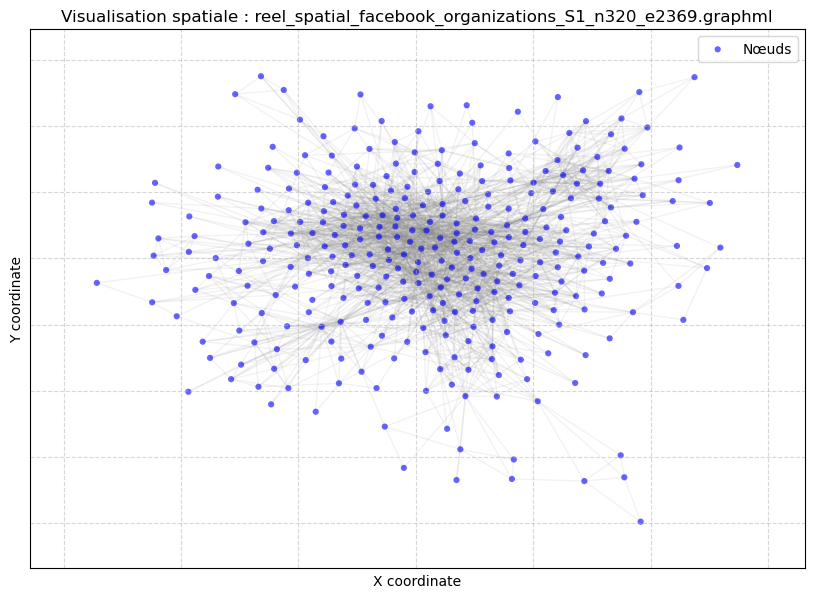

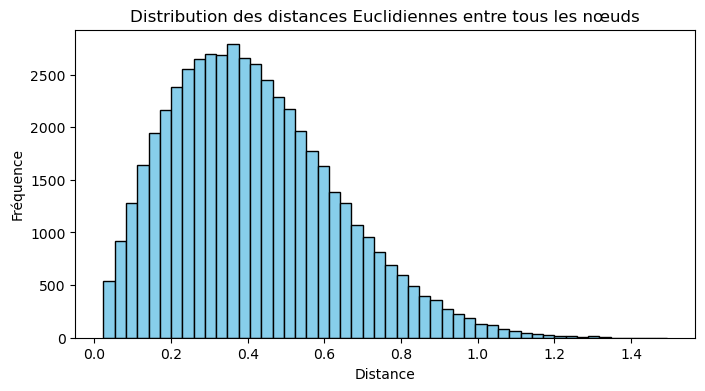

In [5]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import json
from collections import Counter

# 1. Chargement du graphe
file_path = "graph_library/benchmark_graphes_reels/reel_spatial_facebook_organizations_S1_n320_e2369.graphml"
print(f"📖 Chargement de {file_path}...")
G = nx.read_graphml(file_path)

# 2. Extraction et Parsing des positions
# On part du principe que _pos est stocké en string "[x, y]" suite à nos étapes précédentes
positions = {}
raw_coords = []

for node, data in G.nodes(data=True):
    if '_pos' in data:
        # Conversion de la string JSON en liste Python [x, y]
        coords = json.loads(data['_pos'])
        positions[node] = coords
        raw_coords.append(tuple(coords)) # tuple pour pouvoir compter les occurrences

coords_array = np.array(list(positions.values()))

# 3. Statistiques descriptives
unique_coords = set(raw_coords)
counts = Counter(raw_coords)
duplicates = {k: v for k, v in counts.items() if v > 1}

print("\n--- 📊 ANALYSE DES POSITIONS (_pos) ---")
print(f"📍 Nombre total de nœuds : {G.number_of_nodes()}")
print(f"📍 Valeurs distinctes : {len(unique_coords)}")
print(f"📍 Doublons (superpositions) : {len(duplicates)} positions partagées")

if len(raw_coords) > 0:
    print(f"📉 Min (x, y) : {coords_array.min(axis=0)}")
    print(f"📈 Max (x, y) : {coords_array.max(axis=0)}")
    print(f"📏 Étendue (Range) : {coords_array.ptp(axis=0)}")
else:
    print("❌ Aucune donnée de position trouvée !")

# 4. Visualisation 2D
plt.figure(figsize=(10, 7))

# On dessine les arêtes en fond (gris clair et fin pour ne pas polluer)
nx.draw_networkx_edges(G, pos=positions, alpha=0.1, edge_color='gray')

# On dessine les nœuds
sc = plt.scatter(coords_array[:, 0], coords_array[:, 1], 
                 c='blue', s=20, alpha=0.6, edgecolors='none', label='Nœuds')

# Optionnel : Mettre en évidence les doublons s'il y en a
if duplicates:
    dup_coords = np.array(list(duplicates.keys()))
    plt.scatter(dup_coords[:, 0], dup_coords[:, 1], 
                facecolors='none', edgecolors='red', s=50, label='Superpositions')

plt.title(f"Visualisation spatiale : {file_path.split('/')[-1]}")
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 5. Autres idées d'analyses : Distribution des distances
from scipy.spatial.distance import pdist

if len(coords_array) > 1:
    distances = pdist(coords_array)
    plt.figure(figsize=(8, 4))
    plt.hist(distances, bins=50, color='skyblue', edgecolor='black')
    plt.title("Distribution des distances Euclidiennes entre tous les nœuds")
    plt.xlabel("Distance")
    plt.ylabel("Fréquence")
    plt.show()

📥 Chargement du graphe facebook_organizations/S1...

🔍 Propriétés du graphe :
name            (graph)   (type: string, val: facebook_organizations (S1))
description     (graph)   (type: string, val: Six networks of friendships among
                                              users on Facebook who indicated
                                              employment at one of the target
                                              corporation. Companies range in
                                              size from small to large. Only
                                              edges between employees at the
                                              same company are included in a
                                              given snapshot.[^icon] [^icon]:
                                              Description obtained from the
                                              [ICON](https://icon.colorado.edu)
                                              project.)
citation    

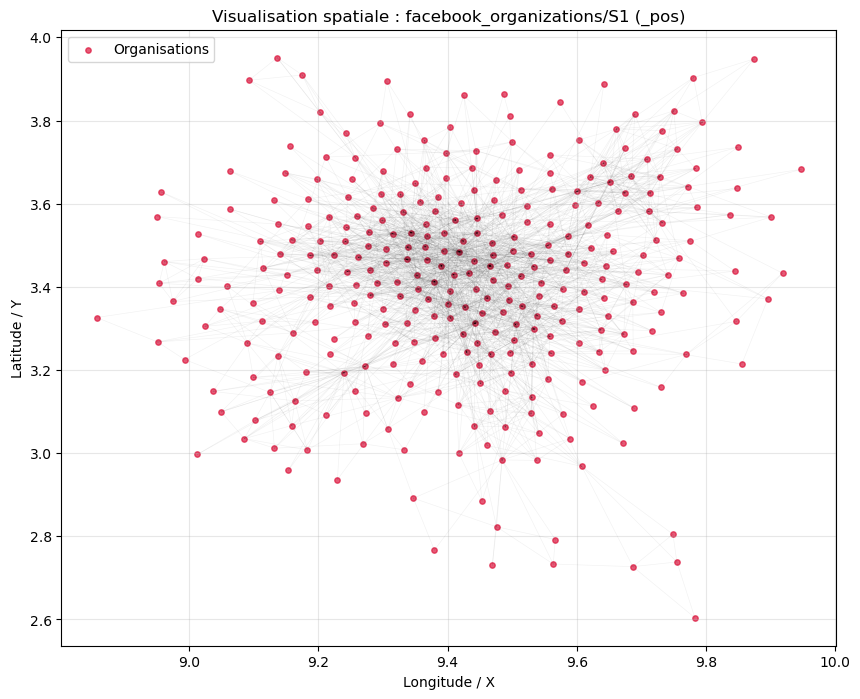

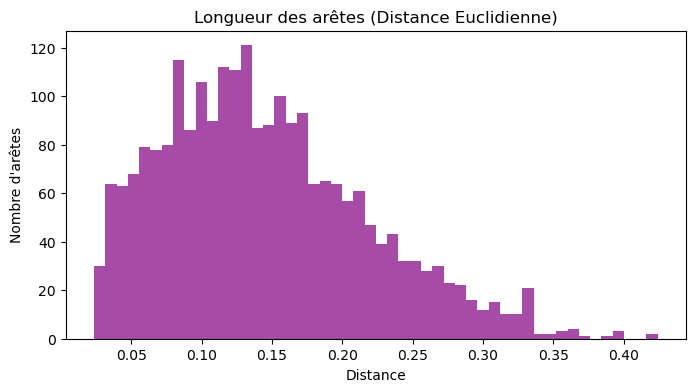

In [5]:
G_name = "Airports"
G_kept = gp.loadsave_data_joblib(filename=f"G_kept_w_struct_com_dist_{G_name}", mode="load")
commus = ["louvain_id", "spatial_louvain_id", 
                "spatial_louvain_manualiter_0_20_id", "spatial_louvain_manualiter_0_50_id", 
                "spatial_louvain_manualiter_0_80_id"]

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import networkx as nx
import numpy as np

# --- 1. Calcul des données ---
data_list = []
m = G_kept.size(weight='weight') if nx.is_weighted(G_kept) else G_kept.size()
N_total = G_kept.number_of_nodes()

for commu_type in commus:
    partition = nx.get_node_attributes(G_kept, commu_type)
    unique_commus = set(partition.values())
    
    # Dictionnaire pour stocker les nœuds de chaque communauté
    communities_dict = {}
    for node, c_id in partition.items():
        communities_dict.setdefault(c_id, []).append(node)
    
    count_skipped = 0
    for c_id, nodes in communities_dict.items():
        size = len(nodes)
        
        # Vérification des singletons (ne peuvent pas avoir de liens internes)
        if size < 2:
            count_skipped += 1
            continue
            
        subgraph = G_kept.subgraph(nodes)
        e_c = subgraph.size(weight='weight') if nx.is_weighted(G_kept) else subgraph.size()
        d_c = sum(dict(G_kept.degree(nodes, weight='weight')).values())
        
        gain_brut = (e_c / m) - (d_c / (2 * m))**2
        qualite = gain_brut / (size / N_total)
        
        try:
            cond = nx.conductance(G_kept, nodes, weight='weight' if nx.is_weighted(G_kept) else None)
        except:
            cond = 1.0

        data_list.append({
            'Type': commu_type,
            'Size': size,
            'Qualite': qualite,
            'Conductance': cond
        })
    
    # Print de vérification pour le chercheur
    print(f"ID: {commu_type:15} | Total commus: {len(unique_commus):<5} | Valid (>1 node): {len(unique_commus)-count_skipped:<5} | Skipped (size 1): {count_skipped}")

df_commu = pd.DataFrame(data_list)

# --- 2. Visualisation avec Jitter pour éviter l'empilement ---
for i, commu_type in enumerate(commus):
    subset = df_commu[df_commu['Type'] == commu_type]
    total_in_plot = len(subset)
    
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 6))
    
    # Titre incluant le nombre total affiché
    fig.suptitle(f"Type: {commu_type} | {total_in_plot} communautés affichées (taille > 1)", 
                 fontsize=16, fontweight='bold', color='navy')

    palette = sns.color_palette("tab10")

    # Plot 1 : Distribution brute (Barres réelles)
    counts = subset['Size'].value_counts().sort_index()
    ax1.bar(counts.index, counts.values, color=palette[i], edgecolor='black', alpha=0.7)
    ax1.set_yscale('log')
    ax1.set_title("Compte exact des tailles (Log scale)")
    ax1.set_xlabel("Taille")
    ax1.set_ylabel("Nombre de communautés")

    # Plot 2 : Qualité avec JITTER vertical
    # Le jitter permet de voir si 50 points sont au même endroit
    sns.stripplot(data=subset, x='Size', y='Qualite', ax=ax2, 
                  color=palette[i], alpha=0.4, jitter=0.2, size=4)
    ax2.axhline(0, color='red', linestyle='--', alpha=0.5)
    ax2.set_title("Qualité vs Taille (avec Jitter)")
    ax2.set_ylabel("Qualité ($\Delta Q / Size\_Rel$)")

    # Plot 3 : Conductance avec JITTER vertical
    sns.stripplot(data=subset, x='Size', y='Conductance', ax=ax3, 
                  color=palette[i], alpha=0.4, jitter=0.2, size=4)
    ax3.set_ylim(-0.05, 1.05)
    ax3.set_title("Conductance vs Taille (avec Jitter)")
    ax3.set_ylabel("Conductance")

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

FileNotFoundError: Fichier introuvable : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/G_kept_w_struct_com_dist_Airports

In [8]:
for i in np.arange(0.00, 1.10, 0.10):
    print("######################################")
    print(f"#### graph sbm {i:.2f} pos {1-i:.2f} ####")
    print("######################################")
    G_name = f"artificial_graph_sbmv4_{f'{i:.2f}'.replace('.', '_')}_pos_{f'{1-i:.2f}'.replace('.', '_')}"
    print(G_name)

    G = load_graphml_safe(f"graph_library/{G_name}.graphml")

    if 'GroundTruth_JSON' in G.graph:
        print(f"[INIT] Extraction de la GT GroundTruth pour {G_name}...")
        gt_raw = json.loads(G.graph['GroundTruth_JSON'])
        raw_pos = gt_raw.get('GT_pos', [])
        gt_pos_array = np.array(raw_pos, dtype=float)

        GT = {'GT_pos': gt_pos_array}

    if GT is not None and 'GT_pos' in GT:
            for i, node_id in enumerate(G.nodes()):
                G.nodes[node_id]['GT_pos'] = GT['GT_pos'][i]

    A = nx.to_numpy_array(G)
    P, nodes = gp.get_gravity_null_model_manual_iterative(G, "GT_pos")
    P_symetric = (P + P.T) / 2
    R_matrix = A - P_symetric

    n_rows = R_matrix.shape[0]

    # Listes pour stocker les résultats intermédiaires de chaque ligne
    row_means_pos = []
    row_means_neg_abs = []
    row_10th_neg_abs = []  
    row_counts_above_mean = []
    rows_with_trigger_count = 0
    
    for i in range(n_rows):
        row = R_matrix[i, :]
        
        # Séparation des valeurs positives et négatives
        pos_vals = row[row > 0]
        neg_vals = row[row < 0]
        
        # 1. Top 10 positifs pour cette ligne
        if len(pos_vals) > 0:
            top10_pos = np.sort(pos_vals)[::-1][:10]
            mean_pos = np.mean(top10_pos)
        else:
            mean_pos = 0.0
        row_means_pos.append(mean_pos)
        
        # 2. Top 10 négatifs (en valeur absolue) pour cette ligne
        if len(neg_vals) > 0:
            abs_neg_vals = np.abs(neg_vals)
            sorted_neg_abs = np.sort(abs_neg_vals)[::-1] # Tri du plus grand au plus petit
            
            # Moyenne du top 10
            mean_neg_abs = np.mean(sorted_neg_abs[:10])
            
            # Récupération du 10ème échantillon (index 9)
            # Sécurité : si la ligne a moins de 10 valeurs négatives, on prend la dernière disponible
            idx_10th = min(9, len(sorted_neg_abs) - 1)
            val_10th = sorted_neg_abs[idx_10th]
        else:
            mean_neg_abs = 0.0
            val_10th = 0.0
            
        row_means_neg_abs.append(mean_neg_abs)
        row_10th_neg_abs.append(val_10th) # <--- Stockage du 10ème élément
            
        # 3. Nb de valeurs négatives (abs) > moyenne positive de la ligne
        if len(neg_vals) > 0:
            count_above_mean = np.sum(np.abs(neg_vals) > mean_pos)
        else:
            count_above_mean = 0
        row_counts_above_mean.append(count_above_mean)
            
        # 4. Suivi pour la proportion (au moins un dépassement sur la ligne)
        if count_above_mean > 0:
            rows_with_trigger_count += 1
    
    # --- Calcul des métriques globales ---
    
    global_mean_pos = np.mean(row_means_pos)
    global_mean_neg_abs = np.mean(row_means_neg_abs)
    global_mean_10th_neg_abs = np.mean(row_10th_neg_abs) # <--- Moyenne globale du 10ème échantillon
    global_mean_count_above = np.mean(row_counts_above_mean)
    proportion_rows = rows_with_trigger_count / n_rows
    
    # --- Affichage des résultats ---
    
    print("==================================================================")
    print(f" RÉSULTATS GLOBAUX DE L'ANALYSE DE LA MATRICE POUR i = {i}")
    print("==================================================================")
    print(f"1. Moyenne globale des (top 10 positifs par ligne)         : {global_mean_pos:.4f}")
    print(f"2. Moyenne globale des (top 10 négatifs abs par ligne)     : {global_mean_neg_abs:.4f}")
    print(f"   ↳ Valeur moyenne du 10ème échantillon négatif (abs)     : {global_mean_10th_neg_abs:.4f}") # <--- Ton ajout
    print(f"3. Nb moyen (par ligne) de négatifs > moyenne pos de la ligne : {global_mean_count_above:.2f}")
    print(f"4. Proportion de lignes ayant au moins un dépassement       : {proportion_rows:.4f} ({proportion_rows * 100:.2f}%)")
    print("==================================================================")

######################################
#### graph sbm 0.00 pos 1.00 ####
######################################
artificial_graph_sbmv4_0_00_pos_1_00
✅ Graphe chargé : 198 nœuds et 2779 liens.
[INIT] Extraction de la GT GroundTruth pour artificial_graph_sbmv4_0_00_pos_1_00...
DIST calculée bieng pour Airports, R = 1.3845640033526252
Iteration 0: MAE = 11.653744, Beta = 2.7593
Modèle gravitaire inféré, avec une MAE de 0.008018222515654429, alpha moy = 0.7225 et beta = 10.806710715349801
Vérification : Null Model donne P.sum / 2*nb_edges = 0.9999999999364133
 RÉSULTATS GLOBAUX DE L'ANALYSE DE LA MATRICE POUR i = 197
1. Moyenne globale des (top 10 positifs par ligne)         : 0.7413
2. Moyenne globale des (top 10 négatifs abs par ligne)     : 0.5383
   ↳ Valeur moyenne du 10ème échantillon négatif (abs)     : 0.4302
3. Nb moyen (par ligne) de négatifs > moyenne pos de la ligne : 3.63
4. Proportion de lignes ayant au moins un dépassement       : 0.4394 (43.94%)
############################